# CE639: AI for Civil Engineering
## Lecture 07: Classification
### Scientific Computing Fundamentals

**Instructors:** Dr. Udit Bhatia & Dr. Sushobhan Sen  
**Tutor:** Sarth Dubey  
**Institution:** IIT Gandhinagar

---

### Learning Objectives

By the end of this notebook, you will be able to:
- Perform logistic regression for binary and multi-class classification
- Explain and visualize decision boundaries
- Address problems of class imbalance using SMOTE and weighted loss
- Evaluate classification models using confusion matrices, ROC, and PR curves
- Apply classification to Civil Engineering problems

## 🔧 Setup and Installation

In [3]:
# Install dependencies (for Google Colab)
import sys
import os
import subprocess

def install_package(package):
    """Install a package using pip."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab ✓")
except:
    IN_COLAB = False
    print("Running locally ✓")

# # Install required packages
# required_packages = ['numpy', 'matplotlib', 'scipy', 'ipywidgets']
# for package in required_packages:
#     try:
#         __import__(package)
#     except ImportError:
#         print(f"Installing {package}...")
#         install_package(package)

# print("\n✓ All packages installed successfully!")

Running locally ✓


In [4]:
if IN_COLAB:
    # !git clone https://github.com/dubeysarth/2026_IITGN_CE639
    # %cd 2026_IITGN_CE639
    subprocess.run(['git', 'clone', 'https://github.com/dubeysarth/2026_IITGN_CE639'])
    os.chdir('2026_IITGN_CE639')

In [6]:
# Import standard libraries
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
%matplotlib inline

# Import our custom helper utilities
import sys
sys.path.append('/content')  # For Colab
sys.path.append('..')  # For local

from utils.Lecture_07 import (
    # Logistic Regression
    sigmoid, softmax, cross_entropy_loss, categorical_cross_entropy_loss,
    logistic_regression_gd, logistic_predict, logistic_predict_class,
    softmax_regression_gd, softmax_predict, softmax_predict_class,
    # Metrics
    confusion_matrix, accuracy, precision, recall, specificity, f1_score,
    compute_all_classification_metrics, roc_curve, pr_curve, auc,
    roc_auc_score, pr_auc_score, plot_confusion_matrix, plot_roc_curve, plot_pr_curve,
    # Class Imbalance
    random_oversample, random_undersample, smote, weighted_cross_entropy,
    compute_class_weights, generate_imbalanced_data, plot_class_distribution,
    # Decision Boundaries
    create_mesh_grid, plot_decision_boundary_2d, plot_sigmoid_curve,
    animate_decision_boundary, plot_multiclass_boundaries, plot_probability_surface_3d,
    # Visualizations
    plot_sigmoid_vs_linear, plot_softmax_demo, plot_loss_landscape_classification,
    plot_training_history, plot_threshold_impact, plot_class_separation,
    # CE Examples
    crack_detection_data, structural_failure_data, soil_classification_data,
    flood_prediction_data, pavement_condition_data, generate_linearly_separable_data,
    # Widgets
    logistic_regression_widget, decision_boundary_widget, class_imbalance_widget,
    confusion_matrix_widget, roc_curve_widget, multiclass_widget
)

print("✓ All imports successful!")
print("=" * 70)
print("Ready to explore Classification!")
print("=" * 70)

✓ All imports successful!
Ready to explore Classification!


---
# 📚 Section 1: Introduction to Classification

## Supervised Learning Recap

Recall from Lecture 6 that supervised learning involves training models on labeled data:

$$\{(\mathbf{x}_i, y_i)\}_{i=1}^n$$

where $\mathbf{x}_i$ are input features and $y_i$ are labels.

### Two Main Types:

1. **Regression**: $y \in \mathbb{R}$ (continuous)
   - Example: Predicting concrete strength (MPa)
   - Loss: MSE, MAE, etc.

2. **Classification**: $y \in \{0, 1, \ldots, K-1\}$ (discrete)
   - Example: Crack detection (crack/no crack)
   - Loss: Cross-entropy

**Key Difference**: Classification predicts **probabilities** of categories, not the categories directly!

## CE Examples of Classification

| Problem | Inputs | Output | Type |
|---------|--------|--------|------|
| Crack Detection | Image features (variance, edges) | Crack/No Crack | Binary |
| Structural Failure | Load ratio, degradation, age | Fail/Safe | Binary (Imbalanced) |
| Soil Classification | Particle size, plasticity | Clay/Sand/Gravel | Multi-class |
| Flood Prediction | Rainfall, river level, saturation | Flood/No Flood | Binary (Imbalanced) |
| Pavement Condition | Roughness, cracks, age | Good/Fair/Poor | Multi-class |

---
# 📐 Section 2: Logistic Regression

## The Sigmoid Function

For binary classification, we need to map real-valued predictions to probabilities $[0, 1]$.

**Sigmoid (Logistic) Function:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where $z = \mathbf{w}^T \mathbf{x} + b$ is the linear combination of inputs.

**Properties:**
- $\sigma(0) = 0.5$ (decision boundary)
- $\sigma(z) \to 1$ as $z \to \infty$
- $\sigma(z) \to 0$ as $z \to -\infty$
- Smooth and differentiable everywhere
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

Sigmoid Function Visualization


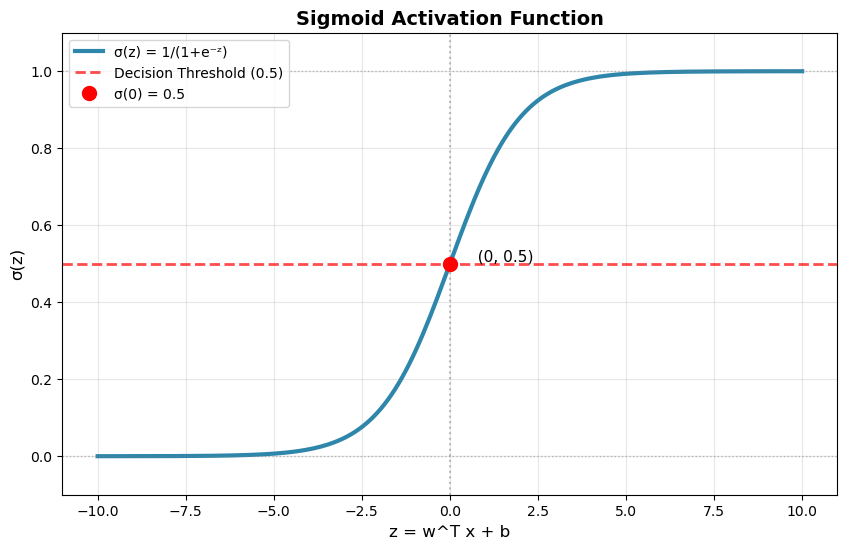


Key Points:
  • σ(0) = 0.5 → Decision boundary
  • σ(z) > 0.5 → Predict class 1
  • σ(z) < 0.5 → Predict class 0
  • Smooth gradient enables gradient descent


In [7]:
# Visualize sigmoid function
print("Sigmoid Function Visualization")
print("=" * 60)

fig, ax = plot_sigmoid_curve(figsize=(10, 6))
plt.show()

print("\nKey Points:")
print("  • σ(0) = 0.5 → Decision boundary")
print("  • σ(z) > 0.5 → Predict class 1")
print("  • σ(z) < 0.5 → Predict class 0")
print("  • Smooth gradient enables gradient descent")

## Sigmoid vs Linear

Why not use a linear function for classification?

**Problems with linear:**
- No bounded output (can predict negative probabilities!)
- No smooth transition between classes
- Gradient is constant (doesn't adapt to confidence)

**Sigmoid advantages:**
- Output always in [0, 1] (valid probability)
- Smooth transition at decision boundary
- Gradient adapts: steep near boundary, flat at extremes

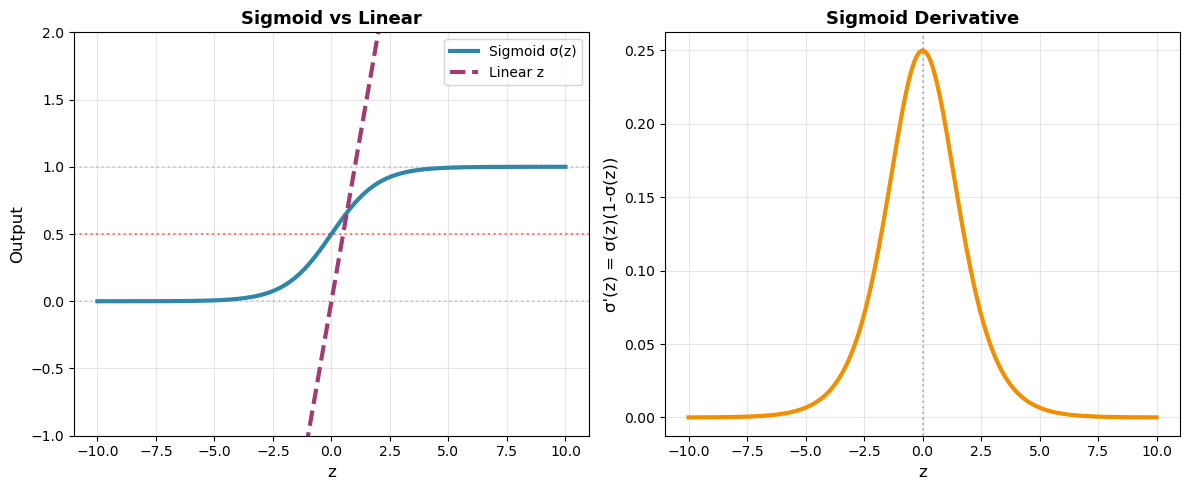


Observations:
  • Linear function unbounded → invalid probabilities
  • Sigmoid derivative peaks at z=0 (decision boundary)
  • Sigmoid saturates at extremes → confident predictions


In [8]:
# Compare sigmoid to linear
fig, axes = plot_sigmoid_vs_linear(figsize=(12, 5))
plt.show()

print("\nObservations:")
print("  • Linear function unbounded → invalid probabilities")
print("  • Sigmoid derivative peaks at z=0 (decision boundary)")
print("  • Sigmoid saturates at extremes → confident predictions")

## Logistic Regression Model

**Model:**

$$\hat{y} = P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

**Prediction:**

$$\text{class} = \begin{cases}
1 & \text{if } \hat{y} \geq 0.5 \\
0 & \text{if } \hat{y} < 0.5
\end{cases}$$

**Parameters to learn:** $\mathbf{w}$ (weights) and $b$ (bias)

Simple 1D Logistic Regression Example
Learned parameters:
  Bias (b):   0.2956
  Weight (w): 3.1100
  Final loss: 0.0442
  Final accuracy: 0.9900


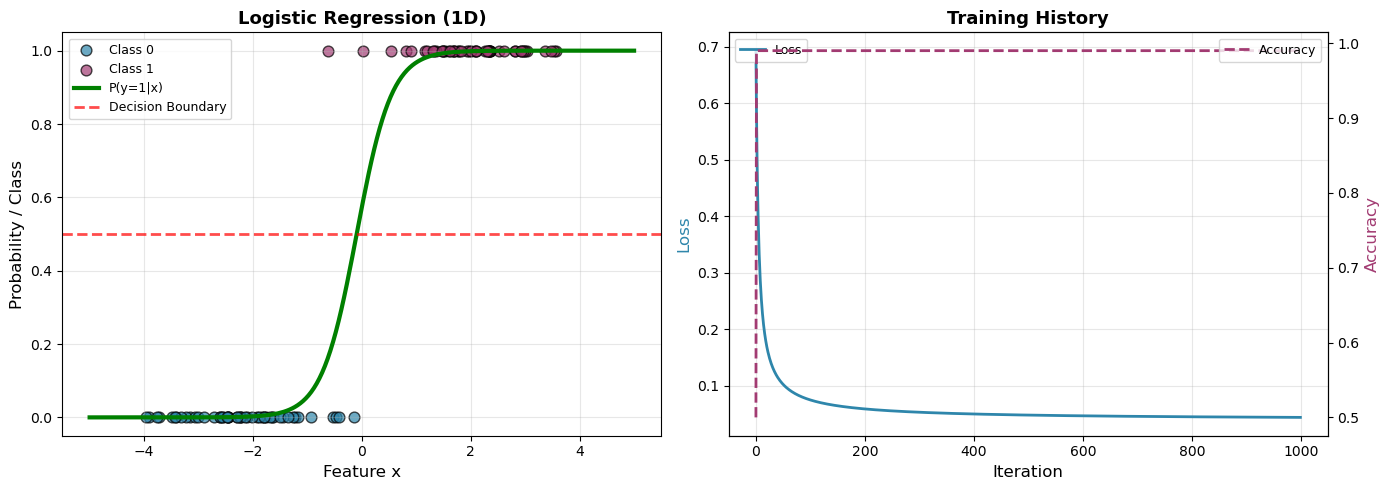

In [9]:
# Demonstrate logistic regression on simple 1D data
print("Simple 1D Logistic Regression Example")
print("=" * 60)

# Generate 1D data
np.random.seed(42)
X_1d = np.concatenate([
    np.random.randn(50) - 2,  # Class 0 centered at -2
    np.random.randn(50) + 2   # Class 1 centered at +2
])
y_1d = np.concatenate([np.zeros(50), np.ones(50)]).astype(int)

# Shuffle
shuffle_idx = np.random.permutation(100)
X_1d = X_1d[shuffle_idx].reshape(-1, 1)
y_1d = y_1d[shuffle_idx]

# Train logistic regression
result = logistic_regression_gd(X_1d, y_1d, learning_rate=0.1, 
                               n_iterations=1000, verbose=False)

print(f"Learned parameters:")
print(f"  Bias (b):   {result['weights'][0]:.4f}")
print(f"  Weight (w): {result['weights'][1]:.4f}")
print(f"  Final loss: {result['loss_history'][-1]:.4f}")
print(f"  Final accuracy: {result['accuracy_history'][-1]:.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Data and decision boundary
x_range = np.linspace(-5, 5, 200).reshape(-1, 1)
y_prob = logistic_predict(x_range, result['weights'])

ax1.scatter(X_1d[y_1d == 0], y_1d[y_1d == 0], c='#2E86AB', s=60, 
           alpha=0.7, edgecolors='black', linewidths=1, label='Class 0')
ax1.scatter(X_1d[y_1d == 1], y_1d[y_1d == 1], c='#A23B72', s=60, 
           alpha=0.7, edgecolors='black', linewidths=1, label='Class 1')
ax1.plot(x_range, y_prob, linewidth=3, color='green', label='P(y=1|x)')
ax1.axhline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, 
           label='Decision Boundary')
ax1.set_xlabel('Feature x', fontsize=12)
ax1.set_ylabel('Probability / Class', fontsize=12)
ax1.set_title('Logistic Regression (1D)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: Training history
ax2.plot(result['loss_history'], linewidth=2, color='#2E86AB', label='Loss')
ax2_twin = ax2.twinx()
ax2_twin.plot(result['accuracy_history'], linewidth=2, color='#A23B72', 
             linestyle='--', label='Accuracy')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12, color='#2E86AB')
ax2_twin.set_ylabel('Accuracy', fontsize=12, color='#A23B72')
ax2.set_title('Training History', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=9)
ax2_twin.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### 🎮 Interactive Widget: Logistic Regression Explorer

In [ ]:
logistic_regression_widget()

interactive(children=(FloatSlider(value=0.1, description='Learning Rate:', max=1.0, min=0.01, step=0.01, style…

---
# 🎯 Section 3: Decision Boundaries

## What is a Decision Boundary?

The **decision boundary** is the surface where $P(y=1|\mathbf{x}) = 0.5$.

For logistic regression:

$$\sigma(\mathbf{w}^T \mathbf{x} + b) = 0.5$$

This occurs when:

$$\mathbf{w}^T \mathbf{x} + b = 0$$

**Geometric interpretation:**
- **1D**: A point
- **2D**: A line
- **3D**: A plane
- **nD**: A hyperplane

**Key insight:** Logistic regression creates **linear** decision boundaries!

2D Decision Boundary Example
Final accuracy: 0.9600
Decision boundary equation: 1.436·x₁ + 1.183·x₂ + -2.940 = 0


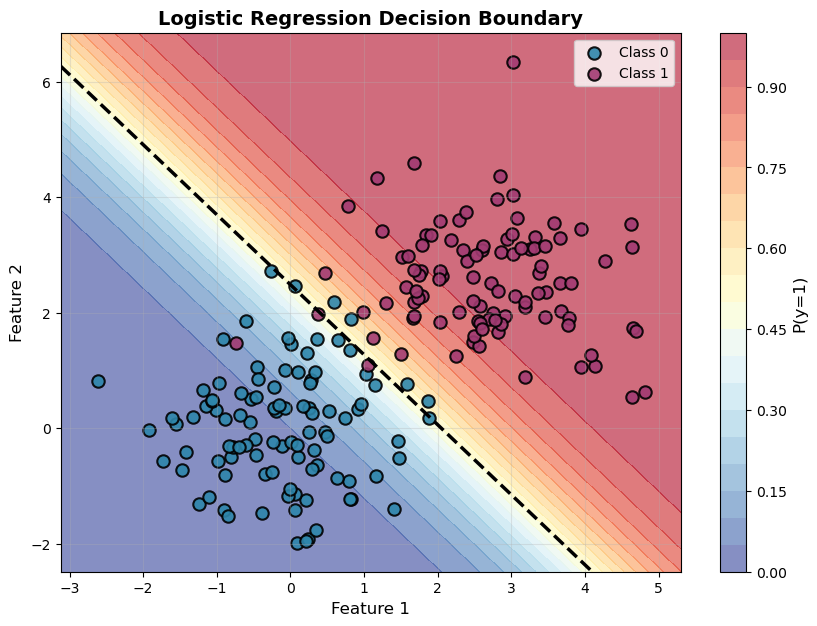

In [11]:
# Visualize 2D decision boundary
print("2D Decision Boundary Example")
print("=" * 60)

# Generate linearly separable 2D data
data = generate_linearly_separable_data(n_samples=200, n_features=2, 
                                       class_sep=2.5, random_state=42)
X_2d = data['X']
y_2d = data['y']

# Train model
result_2d = logistic_regression_gd(X_2d, y_2d, learning_rate=0.1, 
                                  n_iterations=500, verbose=False)

print(f"Final accuracy: {result_2d['accuracy_history'][-1]:.4f}")
print(f"Decision boundary equation: {result_2d['weights'][1]:.3f}·x₁ + "
      f"{result_2d['weights'][2]:.3f}·x₂ + {result_2d['weights'][0]:.3f} = 0")

# Plot decision boundary
def predict_fn(X_test):
    return logistic_predict(X_test, result_2d['weights'])

fig, ax = plot_decision_boundary_2d(X_2d, y_2d, predict_fn, 
                                    title='Logistic Regression Decision Boundary',
                                    figsize=(10, 7))
plt.show()

## Threshold Interpretation

The decision threshold doesn't have to be 0.5!

**Adjusting threshold:**
- **Lower threshold** (e.g., 0.3): More sensitive → higher recall, lower precision
- **Higher threshold** (e.g., 0.7): More specific → lower recall, higher precision

**When to adjust:**
- **Medical diagnosis**: Lower threshold (don't miss cases)
- **Spam detection**: Higher threshold (avoid false positives)
- **Structural failure**: Lower threshold (safety critical)

### 🎮 Interactive Widget: Decision Boundary Explorer

In [12]:
decision_boundary_widget()

interactive(children=(FloatSlider(value=0.5, description='Threshold:', max=1.0, step=0.05, style=SliderStyle(d…

---
# 🔥 Section 4: Cross-Entropy Loss

## Why Not MSE for Classification?

**Mean Squared Error:**

$$L_{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

**Problems:**
1. **Gradient vanishing**: When $\hat{y}$ is very wrong (e.g., $\hat{y}=0.99$ but $y=0$), 
   the sigmoid derivative is near zero → slow learning
2. **Non-convex**: MSE with sigmoid creates non-convex loss landscape → multiple local minima
3. **Inappropriate penalty**: Treats all errors equally, doesn't account for probability interpretation

## Cross-Entropy Loss

**Binary Cross-Entropy (Log Loss):**

$$L(y, \hat{y}) = -(y \log \hat{y} + (1-y) \log(1-\hat{y}))$$

**Interpretation:**
- If $y=1$: $L = -\log \hat{y}$ → penalizes low $\hat{y}$
- If $y=0$: $L = -\log(1-\hat{y})$ → penalizes high $\hat{y}$

**Properties:**
- **Convex** with sigmoid → unique global minimum
- **Large gradients** when wrong → fast learning
- **Probabilistic interpretation**: Negative log-likelihood

**Average over dataset:**

$$J = \frac{1}{n} \sum_{i=1}^n L(y_i, \hat{y}_i)$$

Cross-Entropy Loss Behavior


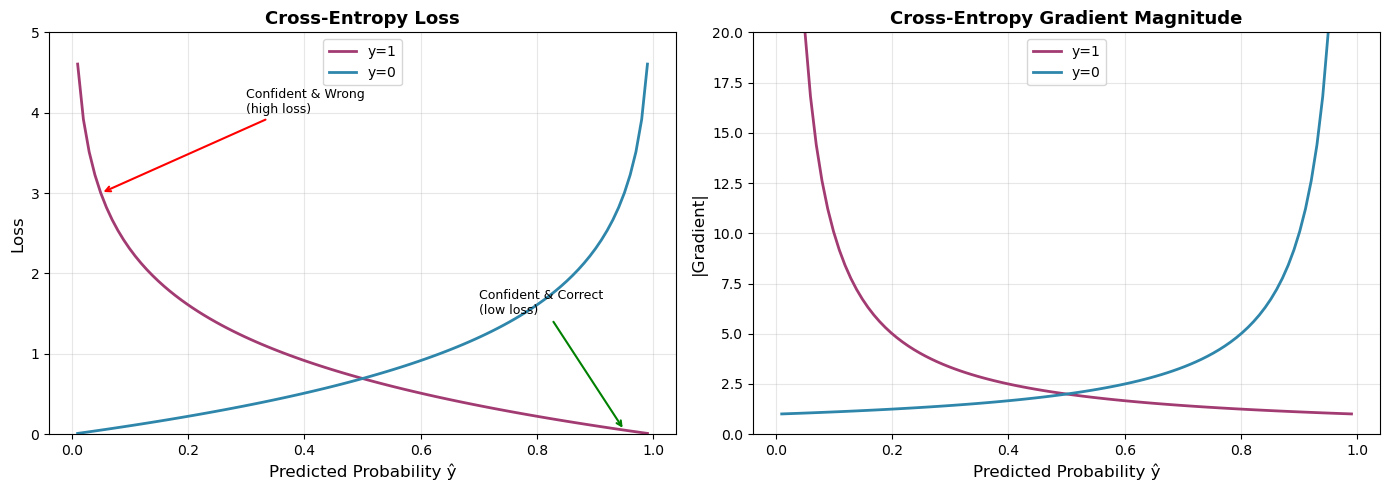


Key Observations:
  • Loss → ∞ when confidently wrong
  • Loss → 0 when confidently correct
  • Gradient large when wrong → fast correction
  • Gradient small when correct → stable convergence


In [13]:
# Demonstrate cross-entropy behavior
print("Cross-Entropy Loss Behavior")
print("=" * 60)

# True label y=1
y_true = 1
y_pred_range = np.linspace(0.01, 0.99, 100)
loss_when_y1 = -np.log(y_pred_range)

# True label y=0
y_true = 0
loss_when_y0 = -np.log(1 - y_pred_range)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss curves
ax1.plot(y_pred_range, loss_when_y1, linewidth=2, color='#A23B72', label='y=1')
ax1.plot(y_pred_range, loss_when_y0, linewidth=2, color='#2E86AB', label='y=0')
ax1.set_xlabel('Predicted Probability ŷ', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Cross-Entropy Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 5])

# Annotate key points
ax1.annotate('Confident & Correct\n(low loss)', xy=(0.95, 0.05), 
            xytext=(0.7, 1.5), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax1.annotate('Confident & Wrong\n(high loss)', xy=(0.05, 3), 
            xytext=(0.3, 4), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Right: Gradient magnitude
gradient_y1 = 1 / y_pred_range  # |dL/dŷ| when y=1
gradient_y0 = 1 / (1 - y_pred_range)  # |dL/dŷ| when y=0

ax2.plot(y_pred_range, gradient_y1, linewidth=2, color='#A23B72', label='y=1')
ax2.plot(y_pred_range, gradient_y0, linewidth=2, color='#2E86AB', label='y=0')
ax2.set_xlabel('Predicted Probability ŷ', fontsize=12)
ax2.set_ylabel('|Gradient|', fontsize=12)
ax2.set_title('Cross-Entropy Gradient Magnitude', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 20])

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("  • Loss → ∞ when confidently wrong")
print("  • Loss → 0 when confidently correct")
print("  • Gradient large when wrong → fast correction")
print("  • Gradient small when correct → stable convergence")

## Loss Landscape Visualization

Let's visualize the cross-entropy loss landscape for a simple 1D problem.

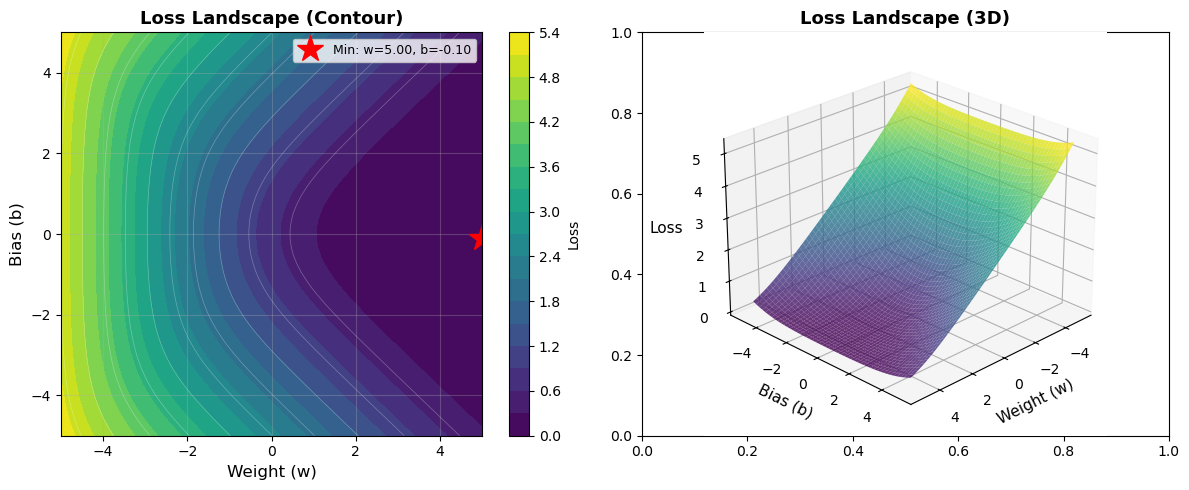


Observations:
  • Loss landscape is convex (bowl-shaped)
  • Single global minimum
  • Gradient descent will converge reliably


In [14]:
# Generate simple 1D data
np.random.seed(42)
X_simple = np.array([[-1], [1]])
y_simple = np.array([0, 1])

# Plot loss landscape
fig, axes = plot_loss_landscape_classification(X_simple, y_simple, 
                                              w_range=(-5, 5), b_range=(-5, 5),
                                              resolution=50, figsize=(12, 5))
plt.show()

print("\nObservations:")
print("  • Loss landscape is convex (bowl-shaped)")
print("  • Single global minimum")
print("  • Gradient descent will converge reliably")

## Gradient Descent for Logistic Regression

**Update rule:**

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \alpha \nabla J(\mathbf{w}_t)$$

**Gradient:**

$$\nabla J = \frac{1}{n} \mathbf{X}^T (\sigma(\mathbf{X}\mathbf{w}) - \mathbf{y})$$

**With L2 regularization:**

$$\nabla J = \frac{1}{n} \mathbf{X}^T (\sigma(\mathbf{X}\mathbf{w}) - \mathbf{y}) + \frac{\lambda}{n} \mathbf{w}$$

**Remarkably similar to linear regression!** The key difference is the sigmoid activation.

---
# 🌈 Section 5: Multi-Class Classification

## Softmax Function

For $K > 2$ classes, we generalize sigmoid to **softmax**:

$$\hat{y}_k = P(y=k|\mathbf{x}) = \frac{\exp(\mathbf{w}_k^T \mathbf{x})}{\sum_{j=1}^K \exp(\mathbf{w}_j^T \mathbf{x})}$$

**Properties:**
- $0 \leq \hat{y}_k \leq 1$ for all $k$
- $\sum_{k=1}^K \hat{y}_k = 1$ (valid probability distribution)
- Amplifies differences (exponential effect)
- Reduces to sigmoid when $K=2$

**Why "softmax"?**
- "Soft" version of argmax (differentiable)
- Larger logits get exponentially higher probabilities

Softmax Function Demonstration
Input logits:  [2.  1.  0.5]
Softmax probs: [0.62853172 0.2312239  0.14024438]
Sum of probs:  1.000000

Winner: Class 0 with probability 0.629


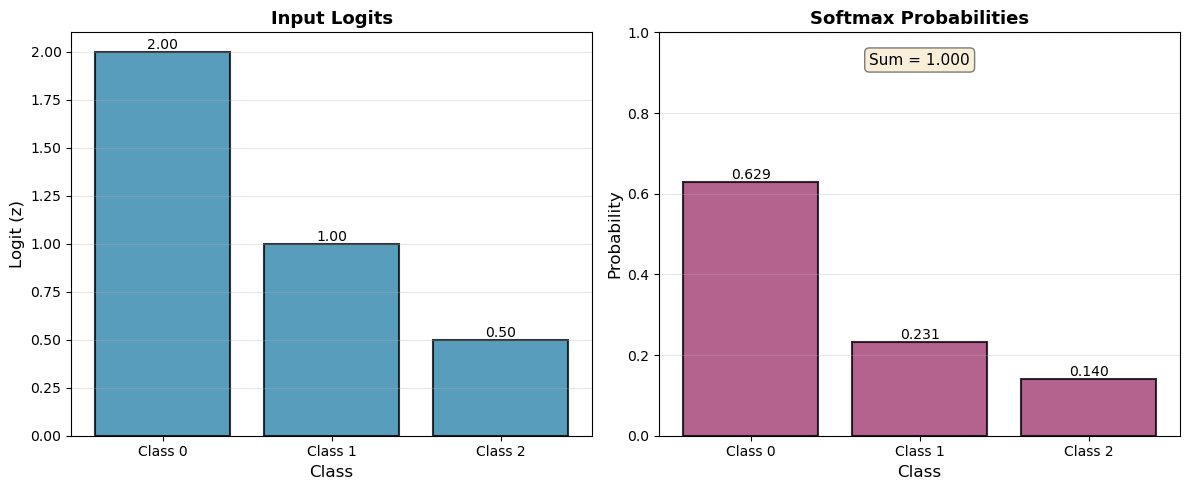

In [15]:
# Demonstrate softmax
print("Softmax Function Demonstration")
print("=" * 60)

# Example logits
z_example = np.array([2.0, 1.0, 0.5])
probs = softmax(z_example.reshape(1, -1))[0]

print(f"Input logits:  {z_example}")
print(f"Softmax probs: {probs}")
print(f"Sum of probs:  {probs.sum():.6f}")
print(f"\nWinner: Class {np.argmax(probs)} with probability {probs.max():.3f}")

# Visualize
fig, axes = plot_softmax_demo(z_values=z_example, figsize=(12, 5))
plt.show()

## Categorical Cross-Entropy

**Loss for multi-class:**

$$L = -\sum_{k=1}^K y_k \log \hat{y}_k$$

where $\mathbf{y}$ is one-hot encoded:

$$\mathbf{y} = [0, 0, \ldots, 1, \ldots, 0]$$

**Simplification:** Only the true class contributes:

$$L = -\log \hat{y}_{\text{true}}$$

## Multi-Class Decision Boundaries

Softmax creates **one decision boundary per class pair**.

For $K$ classes, we have $\binom{K}{2}$ pairwise boundaries.

**Example:** 3 classes → 3 boundaries (0 vs 1, 0 vs 2, 1 vs 2)

CE Example: Soil Classification
Dataset: Soil classification dataset: 600 samples, 3 classes
Features: ['Particle Size (mm)', 'Plasticity Index']
Classes: ['Clay', 'Sand', 'Gravel']

Final accuracy: 0.9950


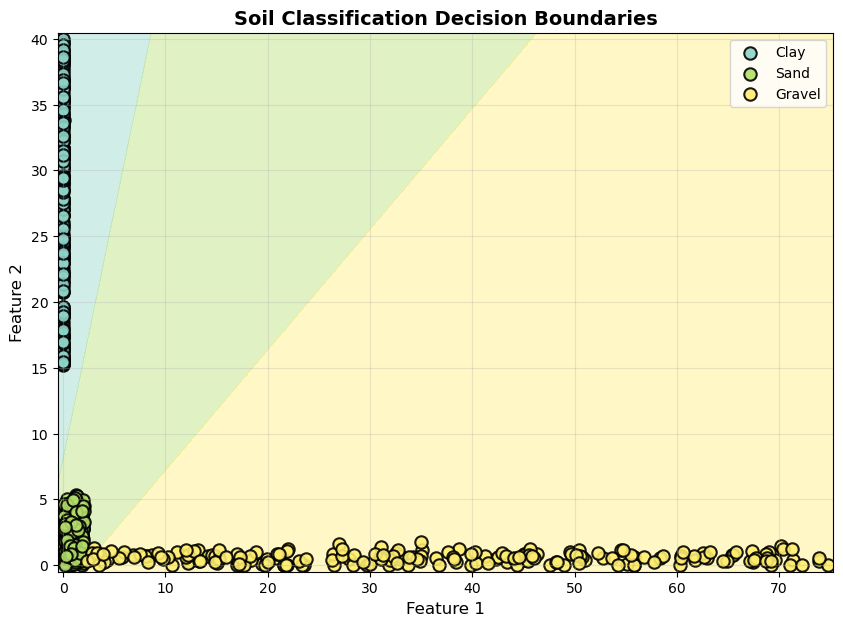

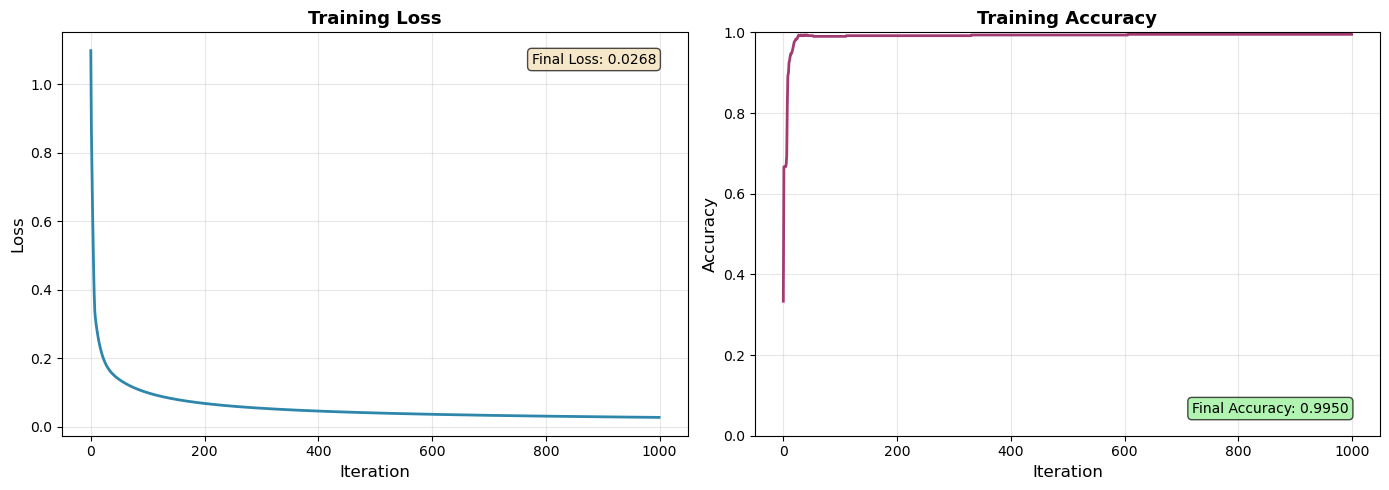

In [16]:
# Multi-class classification example: Soil Classification
print("CE Example: Soil Classification")
print("=" * 60)

# Load soil classification data
data_soil = soil_classification_data(n_samples=600, noise_std=0.15, random_state=42)
X_soil = data_soil['X']
y_soil = data_soil['y']
class_names = data_soil['class_names']

print(f"Dataset: {data_soil['description']}")
print(f"Features: {data_soil['feature_names']}")
print(f"Classes: {class_names}")

# Train softmax regression
result_soil = softmax_regression_gd(X_soil, y_soil, n_classes=3,
                                   learning_rate=0.1, n_iterations=1000, 
                                   verbose=False)

print(f"\nFinal accuracy: {result_soil['accuracy_history'][-1]:.4f}")

# Plot decision boundaries
def predict_soil_fn(X_test):
    return softmax_predict_class(X_test, result_soil['weights'])

fig, ax = plot_multiclass_boundaries(X_soil, y_soil, predict_soil_fn,
                                     class_names=class_names,
                                     title='Soil Classification Decision Boundaries',
                                     figsize=(10, 7))
plt.show()

# Plot training history
fig, axes = plot_training_history(result_soil, figsize=(14, 5))
plt.show()

### 🎮 Interactive Widget: Multi-Class Classification

In [ ]:
multiclass_widget()

interactive(children=(IntSlider(value=3, description='Number of Classes:', max=5, min=2, style=SliderStyle(des…

---
# 📊 Summary of Sections 1-5

We've covered:

1. **Classification Fundamentals**
   - Predicting probabilities of discrete classes
   - CE applications: crack detection, soil classification, flood prediction

2. **Logistic Regression**
   - Sigmoid function maps linear outputs to [0, 1]
   - Model: $P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$

3. **Decision Boundaries**
   - Linear hyperplanes separating classes
   - Threshold adjustment for different applications

4. **Cross-Entropy Loss**
   - Convex, probabilistic loss function
   - Large gradients when wrong → fast learning
   - Superior to MSE for classification

5. **Multi-Class Classification**
   - Softmax generalizes sigmoid to K classes
   - Categorical cross-entropy loss
   - Multiple decision boundaries

**Next:** Class imbalance, confusion matrices, and ROC curves!

---
# ⚖️ Section 6: Class Imbalance Problem

## What is Class Imbalance?

**Class imbalance** occurs when one class has significantly fewer samples than another.

**Common in CE:**
- **Structural failure**: 99% safe, 1% fail
- **Flood events**: 95% no flood, 5% flood
- **Crack detection**: 90% no crack, 10% crack

**The Problem:**
- Standard classifiers optimize for accuracy
- Predicting majority class always → high accuracy but useless!
- **Example**: 99% safe structures → always predict "safe" → 99% accuracy but 0% recall for failures!

Class Imbalance: The Accuracy Paradox
Imbalanced dataset: 1000 samples, 5.0% minority class, 2 features


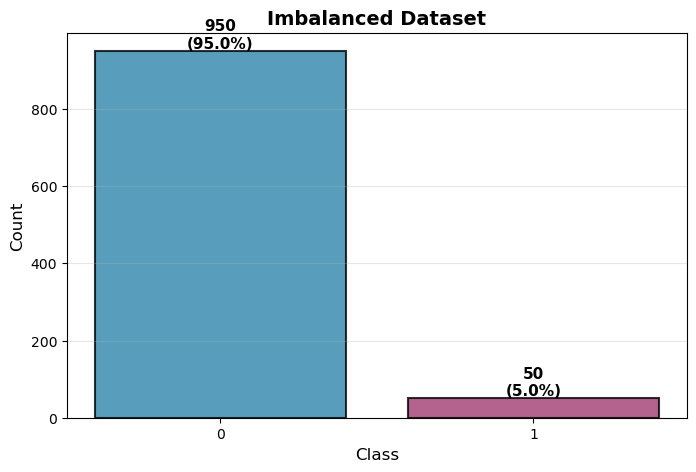


Naive Classifier Metrics:
  Accuracy:  0.976  ← Looks good!
  Precision: 0.933
  Recall:    0.560  ← Terrible! Missing minority class
  F1 Score:  0.700

Confusion Matrix:
  TP: 28, TN: 948
  FP: 2, FN: 22


In [18]:
# Demonstrate the accuracy paradox
print("Class Imbalance: The Accuracy Paradox")
print("=" * 60)

# Generate highly imbalanced data
data_imb = generate_imbalanced_data(n_samples=1000, imbalance_ratio=0.05,
                                   n_features=2, class_sep=2.0, random_state=42)
X_imb = data_imb['X']
y_imb = data_imb['y']

print(f"{data_imb['description']}")

# Plot class distribution
fig, ax = plot_class_distribution(y_imb, title='Imbalanced Dataset', figsize=(8, 5))
plt.show()

# Train naive classifier
result_naive = logistic_regression_gd(X_imb, y_imb, learning_rate=0.1,
                                     n_iterations=500, verbose=False)
y_pred_naive = logistic_predict_class(X_imb, result_naive['weights'])

# Compute metrics
metrics_naive = compute_all_classification_metrics(y_imb, y_pred_naive)

print(f"\nNaive Classifier Metrics:")
print(f"  Accuracy:  {metrics_naive['Accuracy']:.3f}  ← Looks good!")
print(f"  Precision: {metrics_naive['Precision']:.3f}")
print(f"  Recall:    {metrics_naive['Recall']:.3f}  ← Terrible! Missing minority class")
print(f"  F1 Score:  {metrics_naive['F1']:.3f}")
print(f"\nConfusion Matrix:")
print(f"  TP: {metrics_naive['TP']}, TN: {metrics_naive['TN']}")
print(f"  FP: {metrics_naive['FP']}, FN: {metrics_naive['FN']}")

## Solutions: Data-Level

### 1. Random Oversampling
Duplicate minority class samples randomly

### 2. Random Undersampling
Remove majority class samples randomly

### 3. SMOTE (Synthetic Minority Oversampling Technique)
Create synthetic minority samples by interpolating between neighbors

**SMOTE Algorithm:**
1. For each minority sample $\mathbf{x}_i$
2. Find $k$ nearest minority neighbors
3. Randomly select neighbor $\mathbf{x}_{nn}$
4. Create synthetic: $\mathbf{x}_{new} = \mathbf{x}_i + \lambda(\mathbf{x}_{nn} - \mathbf{x}_i)$ where $\lambda \sim U(0,1)$

Comparing Resampling Methods
Original: 1000 samples
After SMOTE: 1900 samples

SMOTE Classifier Metrics (on original test set):
  Accuracy:  0.912
  Precision: 0.352
  Recall:    0.900  ← Much better!
  F1 Score:  0.506


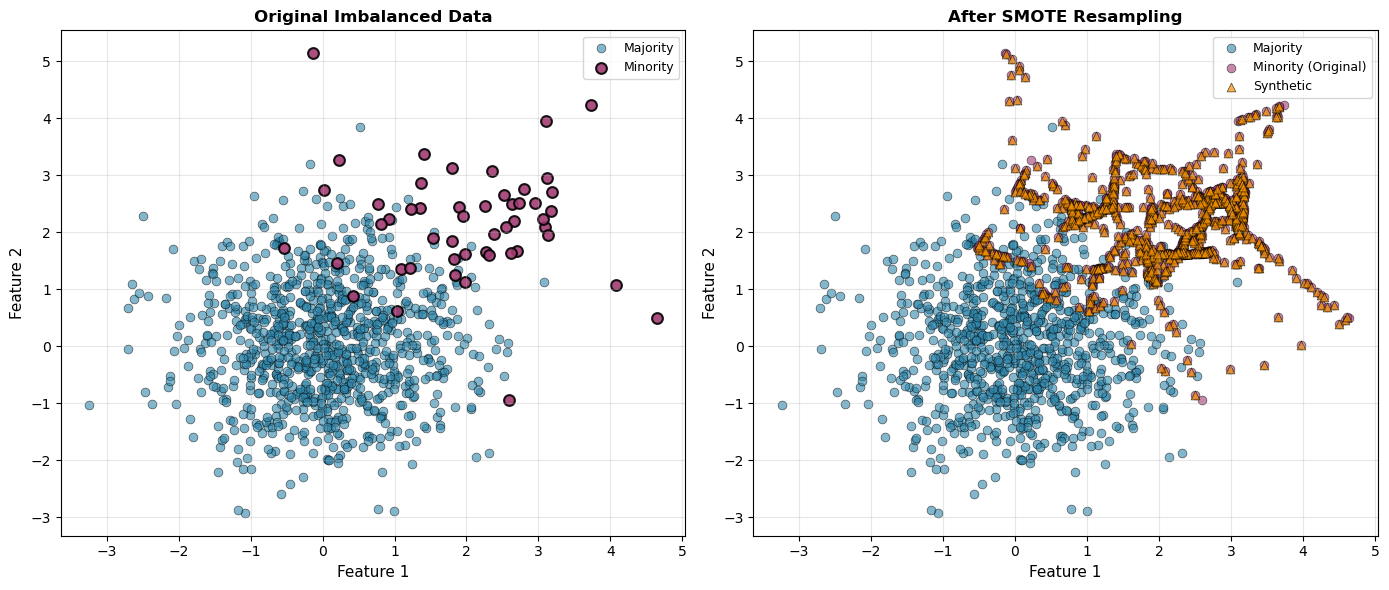

In [19]:
# Compare resampling methods
print("Comparing Resampling Methods")
print("=" * 60)

# Apply SMOTE
X_smote, y_smote = smote(X_imb, y_imb, k_neighbors=5, target_ratio=1.0, random_state=42)

print(f"Original: {len(y_imb)} samples")
print(f"After SMOTE: {len(y_smote)} samples")

# Train on SMOTE data
result_smote = logistic_regression_gd(X_smote, y_smote, learning_rate=0.1,
                                     n_iterations=500, verbose=False)
y_pred_smote = logistic_predict_class(X_imb, result_smote['weights'])  # Test on original

metrics_smote = compute_all_classification_metrics(y_imb, y_pred_smote)

print(f"\nSMOTE Classifier Metrics (on original test set):")
print(f"  Accuracy:  {metrics_smote['Accuracy']:.3f}")
print(f"  Precision: {metrics_smote['Precision']:.3f}")
print(f"  Recall:    {metrics_smote['Recall']:.3f}  ← Much better!")
print(f"  F1 Score:  {metrics_smote['F1']:.3f}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Original data
ax1.scatter(X_imb[y_imb == 0, 0], X_imb[y_imb == 0, 1], c='#2E86AB', s=40,
           alpha=0.6, edgecolors='black', linewidths=0.5, label='Majority')
ax1.scatter(X_imb[y_imb == 1, 0], X_imb[y_imb == 1, 1], c='#A23B72', s=60,
           alpha=0.9, edgecolors='black', linewidths=1.5, label='Minority')
ax1.set_xlabel('Feature 1', fontsize=11)
ax1.set_ylabel('Feature 2', fontsize=11)
ax1.set_title('Original Imbalanced Data', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# After SMOTE
ax2.scatter(X_smote[y_smote == 0, 0], X_smote[y_smote == 0, 1], c='#2E86AB', s=40,
           alpha=0.6, edgecolors='black', linewidths=0.5, label='Majority')
ax2.scatter(X_smote[y_smote == 1, 0], X_smote[y_smote == 1, 1], c='#A23B72', s=40,
           alpha=0.6, edgecolors='black', linewidths=0.5, label='Minority (Original)')
# Highlight synthetic samples
synthetic_mask = np.arange(len(y_smote)) >= len(y_imb)
ax2.scatter(X_smote[synthetic_mask & (y_smote == 1), 0],
           X_smote[synthetic_mask & (y_smote == 1), 1],
           c='#F18F01', s=40, alpha=0.7, marker='^',
           edgecolors='black', linewidths=0.5, label='Synthetic')
ax2.set_xlabel('Feature 1', fontsize=11)
ax2.set_ylabel('Feature 2', fontsize=11)
ax2.set_title('After SMOTE Resampling', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Solutions: Algorithm-Level

### Weighted Loss

Assign higher weight to minority class:

$$L = -w_y (y \log \hat{y} + (1-y) \log(1-\hat{y}))$$

**Common weighting schemes:**
- **Balanced**: $w_i = \frac{n_{total}}{n_{classes} \cdot n_i}$
- **Inverse frequency**: $w_i \propto \frac{1}{n_i}$

In [20]:
# Compute class weights
weights = compute_class_weights(y_imb, method='balanced')
print(f"Class Weights (Balanced):")
print(f"  Class 0 (majority): {weights[0]:.3f}")
print(f"  Class 1 (minority): {weights[1]:.3f}")
print(f"\nMinority class gets {weights[1]/weights[0]:.1f}x higher weight!")

Class Weights (Balanced):
  Class 0 (majority): 0.526
  Class 1 (minority): 10.000

Minority class gets 19.0x higher weight!


### 🎮 Interactive Widget: Class Imbalance Explorer

In [21]:
class_imbalance_widget()

interactive(children=(FloatSlider(value=0.1, description='Imbalance Ratio:', max=0.5, min=0.05, step=0.05, sty…

---
# 🎯 Section 7: Confusion Matrix Deep Dive

## The Confusion Matrix

For binary classification:

|  | Predicted 0 | Predicted 1 |
|---|-------------|-------------|
| **Actual 0** | TN (True Negative) | FP (False Positive) |
| **Actual 1** | FN (False Negative) | TP (True Positive) |

**Derived Metrics:**

- **Accuracy** = $\frac{TP + TN}{TP + TN + FP + FN}$ → Overall correctness

- **Precision** = $\frac{TP}{TP + FP}$ → "Of predicted positives, how many are correct?"

- **Recall (Sensitivity)** = $\frac{TP}{TP + FN}$ → "Of actual positives, how many did we find?"

- **Specificity** = $\frac{TN}{TN + FP}$ → "Of actual negatives, how many did we correctly identify?"

- **F1 Score** = $\frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$ → Harmonic mean

CE Example: Flood Prediction with Confusion Matrix
Flood prediction dataset: 800 samples, 15% flood events
Features: ['Rainfall (mm/day)', 'River Level (m)', 'Soil Saturation']

Metrics:
  Accuracy    : 1.000
  Precision   : 1.000
  Recall      : 1.000
  Specificity : 1.000
  F1          : 1.000


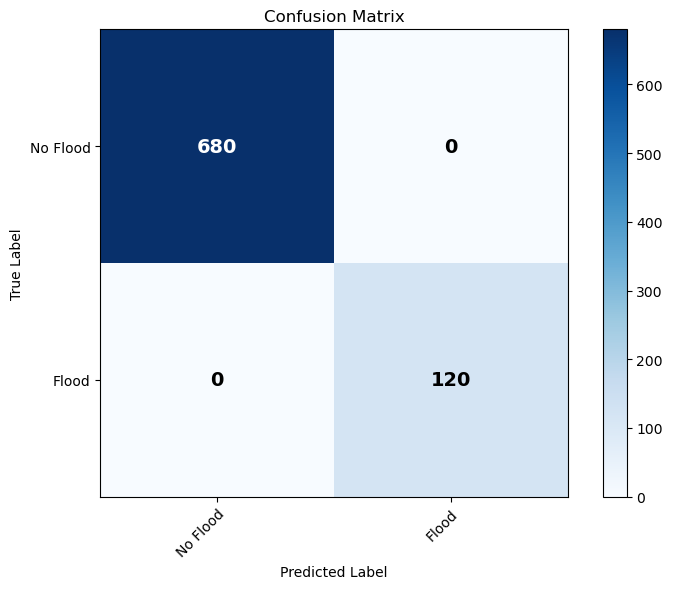


Interpretation:
  • TP=120: Correctly predicted floods
  • FN=0: Missed floods (dangerous!)
  • FP=0: False alarms
  • TN=680: Correctly predicted no flood


In [22]:
# CE Example: Flood Prediction
print("CE Example: Flood Prediction with Confusion Matrix")
print("=" * 60)

# Load flood prediction data
data_flood = flood_prediction_data(n_samples=800, flood_rate=0.15, random_state=42)
X_flood = data_flood['X']
y_flood = data_flood['y']

print(f"{data_flood['description']}")
print(f"Features: {data_flood['feature_names']}")

# Train model
result_flood = logistic_regression_gd(X_flood, y_flood, learning_rate=0.05,
                                     n_iterations=1000, verbose=False)
y_prob_flood = logistic_predict(X_flood, result_flood['weights'])
y_pred_flood = (y_prob_flood >= 0.5).astype(int)

# Compute confusion matrix
cm_flood = confusion_matrix(y_flood, y_pred_flood)
metrics_flood = compute_all_classification_metrics(y_flood, y_pred_flood)

print(f"\nMetrics:")
for metric in ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1']:
    print(f"  {metric:12s}: {metrics_flood[metric]:.3f}")

# Plot confusion matrix
fig, ax = plot_confusion_matrix(cm_flood, class_names=['No Flood', 'Flood'],
                                normalize=False, figsize=(8, 6))
plt.show()

print(f"\nInterpretation:")
print(f"  • TP={metrics_flood['TP']}: Correctly predicted floods")
print(f"  • FN={metrics_flood['FN']}: Missed floods (dangerous!)")
print(f"  • FP={metrics_flood['FP']}: False alarms")
print(f"  • TN={metrics_flood['TN']}: Correctly predicted no flood")

### 🎮 Interactive Widget: Confusion Matrix Explorer

In [23]:
confusion_matrix_widget()

interactive(children=(FloatSlider(value=0.5, description='Threshold:', max=1.0, step=0.05, style=SliderStyle(d…

---
# �� Section 8: ROC & PR Curves

## ROC Curve (Receiver Operating Characteristic)

**Plots:** TPR (y-axis) vs FPR (x-axis) at different thresholds

- **TPR (True Positive Rate)** = Recall = $\frac{TP}{TP + FN}$
- **FPR (False Positive Rate)** = $\frac{FP}{FP + TN}$ = 1 - Specificity

**AUC (Area Under Curve):**
- AUC = 1.0: Perfect classifier
- AUC = 0.5: Random guessing
- AUC < 0.5: Worse than random (flip predictions!)

**Interpretation:**
- Top-left corner = ideal (TPR=1, FPR=0)
- Diagonal = random classifier
- Higher AUC = better overall performance

ROC Curve Analysis
ROC AUC: 0.999


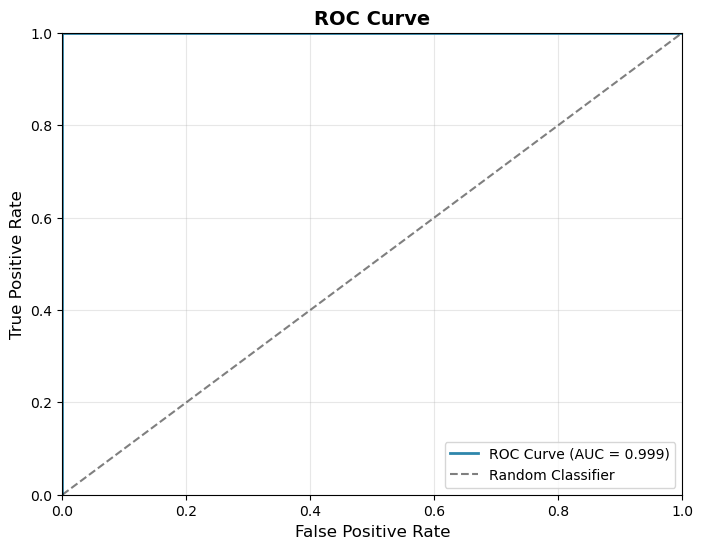

In [24]:
# Compute and plot ROC curve
print("ROC Curve Analysis")
print("=" * 60)

roc = roc_curve(y_flood, y_prob_flood)
roc_auc = roc_auc_score(y_flood, y_prob_flood)

print(f"ROC AUC: {roc_auc:.3f}")

fig, ax = plot_roc_curve(roc['fpr'], roc['tpr'], auc_score=roc_auc, figsize=(8, 6))
plt.show()

## PR Curve (Precision-Recall)

**Plots:** Precision (y-axis) vs Recall (x-axis) at different thresholds

**When to use PR over ROC:**
- **Imbalanced datasets**: PR curve more informative
- **Focus on positive class**: When FP matters more than TN

**Baseline:**
- Random classifier: Precision = fraction of positive class
- Example: 10% positive → random precision = 0.1

PR AUC: 0.993


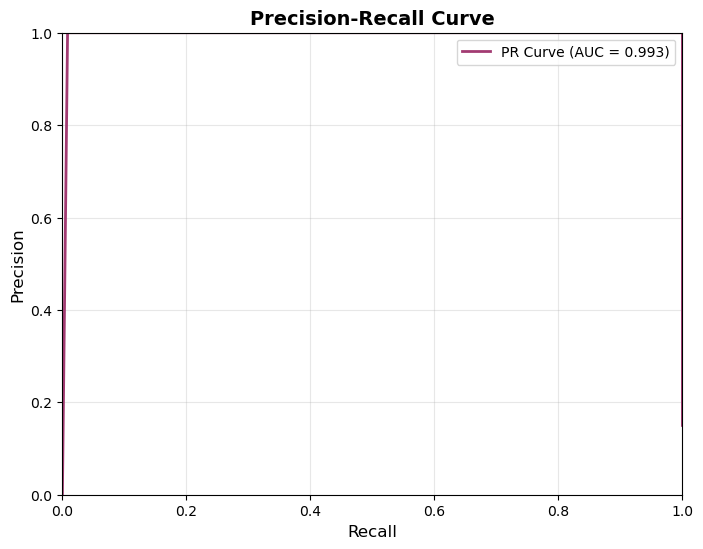


Comparison:
  ROC AUC: 0.999
  PR AUC:  0.993

For imbalanced data, PR curve is more informative!


In [25]:
# Compute and plot PR curve
pr = pr_curve(y_flood, y_prob_flood)
pr_auc = pr_auc_score(y_flood, y_prob_flood)

print(f"PR AUC: {pr_auc:.3f}")

fig, ax = plot_pr_curve(pr['recall'], pr['precision'], auc_score=pr_auc, figsize=(8, 6))
plt.show()

print(f"\nComparison:")
print(f"  ROC AUC: {roc_auc:.3f}")
print(f"  PR AUC:  {pr_auc:.3f}")
print(f"\nFor imbalanced data, PR curve is more informative!")

### 🎮 Interactive Widget: ROC Curve Explorer

In [26]:
roc_curve_widget()

interactive(children=(FloatSlider(value=0.5, description='Threshold:', max=1.0, step=0.05, style=SliderStyle(d…

---
# 🏗️ Section 9: CE Application - Structural Failure Prediction

CE Application: Structural Failure Prediction
Structural failure dataset: 1000 samples, 5.0% failure rate (rare event)
Features: ['Load Ratio', 'Material Degradation', 'Age (years)']
Note: Showing first 2 features only for visualization


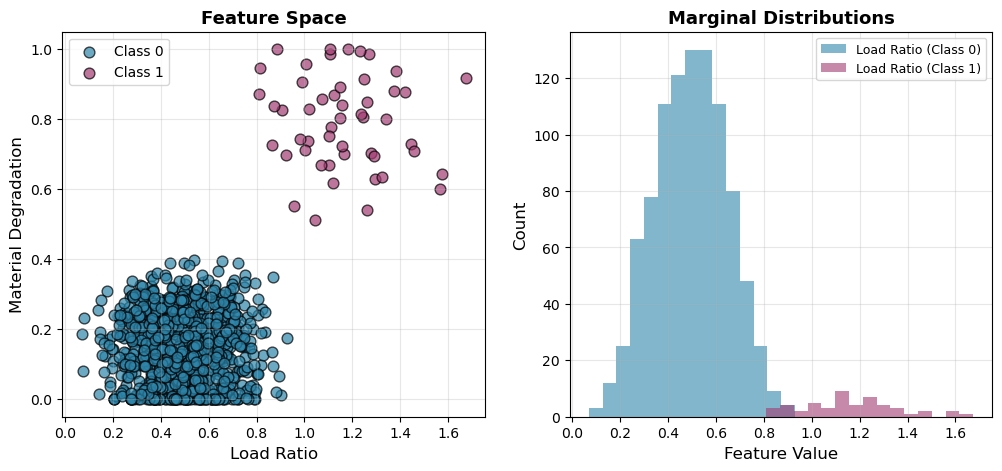


Metrics (threshold=0.3 for safety):
  Accuracy    : 0.996
  Precision   : 0.926
  Recall      : 1.000
  F1          : 0.962


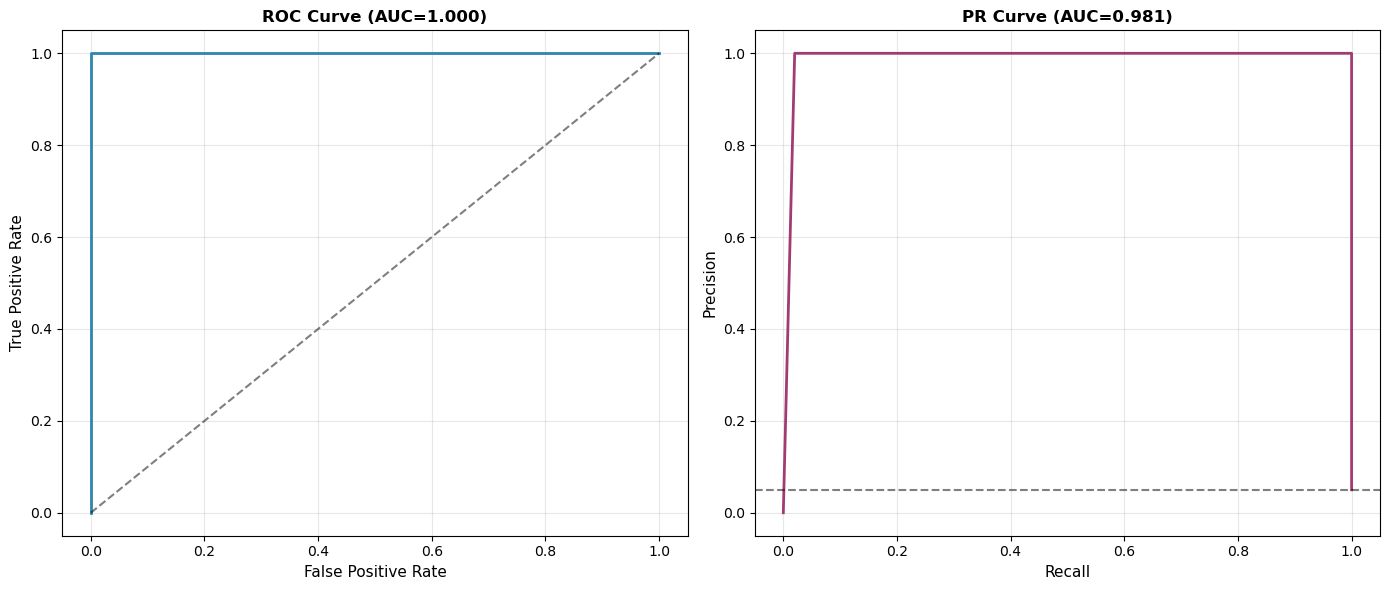


Key Insight: Lower threshold (0.3) increases recall
→ Better at catching failures (safety critical!)


In [27]:
# Load structural failure data (rare event)
print("CE Application: Structural Failure Prediction")
print("=" * 60)

data_failure = structural_failure_data(n_samples=1000, failure_rate=0.05, random_state=42)
X_failure = data_failure['X']
y_failure = data_failure['y']

print(f"{data_failure['description']}")
print(f"Features: {data_failure['feature_names']}")

# Visualize class separation
fig, axes = plot_class_separation(X_failure, y_failure,
                                  feature_names=data_failure['feature_names'],
                                  figsize=(12, 5))
plt.show()

# Train with SMOTE to handle imbalance
X_failure_smote, y_failure_smote = smote(X_failure, y_failure, k_neighbors=3,
                                         target_ratio=0.5, random_state=42)

result_failure = logistic_regression_gd(X_failure_smote, y_failure_smote,
                                       learning_rate=0.05, n_iterations=1500,
                                       lambda_reg=0.1, verbose=False)

# Evaluate on original data
y_prob_failure = logistic_predict(X_failure, result_failure['weights'])
y_pred_failure = (y_prob_failure >= 0.3).astype(int)  # Lower threshold for safety

metrics_failure = compute_all_classification_metrics(y_failure, y_pred_failure)

print(f"\nMetrics (threshold=0.3 for safety):")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    print(f"  {metric:12s}: {metrics_failure[metric]:.3f}")

# ROC and PR curves
roc_failure = roc_curve(y_failure, y_prob_failure)
pr_failure = pr_curve(y_failure, y_prob_failure)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC
ax1.plot(roc_failure['fpr'], roc_failure['tpr'], linewidth=2, color='#2E86AB')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title(f'ROC Curve (AUC={roc_auc_score(y_failure, y_prob_failure):.3f})',
             fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# PR
ax2.plot(pr_failure['recall'], pr_failure['precision'], linewidth=2, color='#A23B72')
baseline = np.sum(y_failure) / len(y_failure)
ax2.axhline(baseline, color='k', linestyle='--', linewidth=1.5, alpha=0.5)
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title(f'PR Curve (AUC={pr_auc_score(y_failure, y_prob_failure):.3f})',
             fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey Insight: Lower threshold (0.3) increases recall")
print(f"→ Better at catching failures (safety critical!)")

---
# 🛣️ Section 10: CE Application - Pavement Condition

CE Application: Pavement Condition Assessment
Pavement condition dataset: 900 samples, 3 classes
Features: ['Surface Roughness (IRI)', 'Crack Density (%)', 'Age (years)']
Classes: ['Good', 'Fair', 'Poor']

Final accuracy: 0.8778


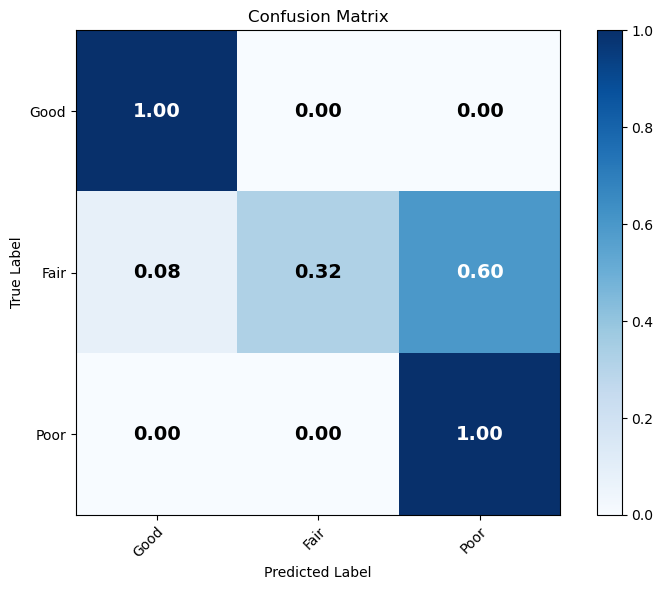


Per-Class Metrics:
  Good    : Precision=0.926, Recall=1.000, F1=0.962
  Fair    : Precision=1.000, Recall=0.323, F1=0.489
  Poor    : Precision=0.626, Recall=1.000, F1=0.770


In [28]:
# Multi-class pavement condition assessment
print("CE Application: Pavement Condition Assessment")
print("=" * 60)

data_pavement = pavement_condition_data(n_samples=900, random_state=42)
X_pavement = data_pavement['X']
y_pavement = data_pavement['y']
class_names_pav = data_pavement['class_names']

print(f"{data_pavement['description']}")
print(f"Features: {data_pavement['feature_names']}")
print(f"Classes: {class_names_pav}")

# Train softmax regression
result_pavement = softmax_regression_gd(X_pavement, y_pavement, n_classes=3,
                                       learning_rate=0.05, n_iterations=1500,
                                       lambda_reg=0.1, verbose=False)

y_pred_pavement = softmax_predict_class(X_pavement, result_pavement['weights'])

print(f"\nFinal accuracy: {result_pavement['accuracy_history'][-1]:.4f}")

# Multi-class confusion matrix
cm_pavement = confusion_matrix(y_pavement, y_pred_pavement, n_classes=3)

fig, ax = plot_confusion_matrix(cm_pavement, class_names=class_names_pav,
                                normalize=True, figsize=(8, 6))
plt.show()

# Per-class metrics
print(f"\nPer-Class Metrics:")
for class_idx, class_name in enumerate(class_names_pav):
    # Binary problem: this class vs rest
    y_binary = (y_pavement == class_idx).astype(int)
    y_pred_binary = (y_pred_pavement == class_idx).astype(int)
    
    prec = precision(y_binary, y_pred_binary)
    rec = recall(y_binary, y_pred_binary)
    f1 = f1_score(y_binary, y_pred_binary)
    
    print(f"  {class_name:8s}: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

---
# 🎓 Section 11: Summary & Key Takeaways

## Complete Classification Pipeline

1. **Data Preparation**
   - Check for class imbalance
   - Apply SMOTE or weighted loss if needed
   - Feature scaling (standardization)

2. **Model Training**
   - Binary: Logistic regression with sigmoid
   - Multi-class: Softmax regression
   - Optimize cross-entropy loss with gradient descent
   - Add L2 regularization if needed

3. **Threshold Selection**
   - Default: 0.5
   - Safety-critical: Lower threshold (higher recall)
   - Cost-sensitive: Adjust based on FP/FN costs

4. **Evaluation**
   - **Never use accuracy alone!**
   - Confusion matrix: TP, TN, FP, FN
   - Precision, Recall, F1 score
   - ROC curve (balanced data)
   - PR curve (imbalanced data)

5. **Deployment Considerations**
   - Monitor for distribution shift
   - Retrain periodically
   - A/B testing for threshold tuning

## Key Insights for CE Applications

### Structural Safety (Failure Prediction)
- **Imbalanced**: Failures are rare
- **Metric**: Prioritize **recall** (don't miss failures!)
- **Threshold**: Lower than 0.5
- **Solution**: SMOTE + weighted loss

### Flood Prediction
- **Imbalanced**: Floods are rare events
- **Metric**: F1 score balances precision and recall
- **Curve**: PR curve more informative than ROC

### Soil/Pavement Classification
- **Multi-class**: Softmax regression
- **Metric**: Per-class precision and recall
- **Visualization**: Multi-class confusion matrix

## Common Pitfalls

1. **Using accuracy for imbalanced data** → Misleading!
2. **Ignoring class imbalance** → Poor minority class performance
3. **Fixed threshold at 0.5** → Not optimal for all applications
4. **Using ROC for highly imbalanced data** → Use PR curve instead
5. **Not regularizing** → Overfitting, especially with many features

## Edge Cases to Consider

### Perfect Separation
- Logistic regression weights → ∞
- Solution: Add regularization

### Extreme Imbalance (99.9% vs 0.1%)
- SMOTE may create too many synthetic samples
- Solution: Combine with undersampling or use weighted loss

### Multi-class with Overlapping Classes
- Decision boundaries become complex
- Solution: Consider non-linear kernels or neural networks

### High-dimensional Features
- Curse of dimensionality
- Solution: Feature selection, PCA, or regularization

---
# 🎯 Final Exercise

Try the crack detection dataset with different techniques:

In [29]:
# Final comprehensive example
print("Final Exercise: Crack Detection")
print("=" * 60)

data_crack = crack_detection_data(n_samples=500, imbalance_ratio=0.2, random_state=42)
X_crack = data_crack['X']
y_crack = data_crack['y']

print(f"{data_crack['description']}")

# Train baseline
result_baseline = logistic_regression_gd(X_crack, y_crack, learning_rate=0.1,
                                        n_iterations=1000, verbose=False)

# Train with SMOTE
X_crack_smote, y_crack_smote = smote(X_crack, y_crack, target_ratio=1.0, random_state=42)
result_smote_crack = logistic_regression_gd(X_crack_smote, y_crack_smote,
                                           learning_rate=0.1, n_iterations=1000,
                                           verbose=False)

# Compare
y_pred_baseline = logistic_predict_class(X_crack, result_baseline['weights'])
y_pred_smote = logistic_predict_class(X_crack, result_smote_crack['weights'])

metrics_baseline_crack = compute_all_classification_metrics(y_crack, y_pred_baseline)
metrics_smote_crack = compute_all_classification_metrics(y_crack, y_pred_smote)

print(f"\nBaseline vs SMOTE Comparison:")
print(f"{'Metric':<12} {'Baseline':>10} {'SMOTE':>10} {'Improvement':>12}")
print("-" * 50)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    baseline_val = metrics_baseline_crack[metric]
    smote_val = metrics_smote_crack[metric]
    improvement = smote_val - baseline_val
    print(f"{metric:<12} {baseline_val:>10.3f} {smote_val:>10.3f} {improvement:>+12.3f}")

Final Exercise: Crack Detection
Crack detection dataset: 500 samples, 20% crack samples

Baseline vs SMOTE Comparison:
Metric         Baseline      SMOTE  Improvement
--------------------------------------------------
Accuracy          0.980      0.964       -0.016
Precision         1.000      0.866       -0.134
Recall            0.900      0.970       +0.070
F1                0.947      0.915       -0.032


---
# 🎉 Congratulations!

You've completed the Classification lecture! You now know how to:

✅ Perform logistic regression for binary and multi-class problems  
✅ Visualize and interpret decision boundaries  
✅ Handle class imbalance with SMOTE and weighted loss  
✅ Evaluate models using confusion matrices, ROC, and PR curves  
✅ Apply classification to real CE problems  

**Next Lecture:** Clustering & Unsupervised Learning